# 使用 SNN 直接训练 NinaPro 滑动窗口原始数据（T=120）

原始窗口包含 40 个 sEMG 采样点，覆盖 200 ms。本 Notebook 通过零阶保持将每个采样点重复 3 次，使输入成为 120 个 SNN 时间步；该操作只细化离散时间轴，不增加新的测量信息。`TAU` 固定为 2.0，以便与 T=40 实验保持相同的网络超参数。

训练期间每个 epoch 都在测试集上评估，并按测试准确率保存 `best.pt`。因此该最佳模型属于 **test-selected checkpoint**，其结果不能视为完全无偏的最终测试估计。

In [1]:
# 设置工作目录，导入依赖包
from pathlib import Path


def find_project_root():
    """从当前目录向上查找项目根目录。"""
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "src").is_dir() and (candidate / "ninapro_data").is_dir():
            return candidate
    raise FileNotFoundError("未找到同时包含 src 和 ninapro_data 的项目根目录。")


PROJECT_ROOT = find_project_root()

# 将项目根目录加入导入路径，兼容从项目根目录或 Notebook 目录启动。
import sys
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"PROJECT_ROOT = {PROJECT_ROOT}")

PROJECT_ROOT = /root/autodl-tmp/NinaPro


## 1. 参数定义

In [2]:
SOURCE_T = 40
T = 120
DATA_DIR = PROJECT_ROOT / "ninapro_data" / "processed" / "exerciseA" / "slide_window"

if T % SOURCE_T != 0:
    raise ValueError("目标时间步必须是原始 40 帧的整数倍")
REPEAT_FACTOR = T // SOURCE_T

NUM_WORKERS = 8
# 训练参数
BATCH_SIZE = 512
EPOCHS = 100
LEARNING_RATE = 1e-2
WEIGHT_DECAY = 1e-4  # 增大 weight_decay 以减少过拟合
GRADIENT_CLIP = 1.0
SEED = 42
DETERMINISTIC = False
MIXED_PRECISION = True
EVAL_INTERVAL = 1
CHECKPOINT_INTERVAL = 5

# 模型参数；TAU 在不同 T 的实验中保持不变。
INPUT_CHANNELS = 16
HIDDEN_SIZE = 64
NUM_CLASSES = 12
TAU = 2.0
DROPOUT_RATE = 0.1

# 训练结果输出目录
MODEL_NAME = "DropoutPLIFSNN"
EXPERIMENT_NAME = f"{MODEL_NAME}_BATCH_SIZE{BATCH_SIZE}_LR{LEARNING_RATE}_HIDDEN{HIDDEN_SIZE}_DROPOUT{DROPOUT_RATE}_TAU{TAU}_WD{WEIGHT_DECAY}"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "raw_ninapro_snn" / f"T_{T}" / EXPERIMENT_NAME

# 单批次诊断不会修改正式模型，可在确认链路正确后关闭。
RUN_OVERFIT_CHECK = False
OVERFIT_MAX_STEPS = 500
OVERFIT_TARGET_ACCURACY = 0.99
OVERFIT_SAMPLES_PER_CLASS = 2

# 仅在需要显式恢复训练时设置为 last.pt 路径。
RESUME_FROM = None

print(f"DATA_DIR = {DATA_DIR}")
print(f"SOURCE_T = {SOURCE_T}, T = {T}, REPEAT_FACTOR = {REPEAT_FACTOR}")
print(f"MODEL_NAME = {MODEL_NAME}")
print(f"OUTPUT_DIR = {OUTPUT_DIR}")

DATA_DIR = /root/autodl-tmp/NinaPro/ninapro_data/processed/exerciseA/slide_window
SOURCE_T = 40, T = 120, REPEAT_FACTOR = 3
MODEL_NAME = DropoutPLIFSNN
OUTPUT_DIR = /root/autodl-tmp/NinaPro/outputs/raw_ninapro_snn/T_120/DropoutPLIFSNN_BATCH_SIZE512_LR0.01_HIDDEN64_DROPOUT0.1_TAU2.0_WD0.0001


## 2. 随机种子与设备

In [3]:
from src.training import resolve_device, seed_everything

seed_everything(SEED, deterministic=DETERMINISTIC)
DEVICE = resolve_device()
print(f"DEVICE = {DEVICE}")

DEVICE = cuda


## 3. 数据与零阶保持时间扩展

In [4]:
import torch

from src.data import ComposeTransforms, create_data_pipeline


class ZeroOrderHoldTimeExpansion:
    "通过重复原始采样点，将 40 帧扩展到目标 SNN 时间步。"

    def __init__(self, source_steps, target_steps):
        if target_steps % source_steps != 0:
            raise ValueError("target_steps 必须是 source_steps 的整数倍")
        self.source_steps = source_steps
        self.target_steps = target_steps
        self.repeat_factor = target_steps // source_steps

    def __call__(self, x):
        if not isinstance(x, torch.Tensor):
            raise TypeError("零阶保持的输入必须是 torch.Tensor")
        if x.shape[-1] != self.source_steps:
            raise ValueError(
                f"原始时间维应为 {self.source_steps}，实际为 {x.shape[-1]}"
            )
        # 每个 5 ms 原始采样值在更细的 SNN 时间网格上保持不变。
        return x.repeat_interleave(self.repeat_factor, dim=-1)

    def __repr__(self):
        return (
            f"{self.__class__.__name__}(source_steps={self.source_steps}, "
            f"target_steps={self.target_steps}, repeat_factor={self.repeat_factor})"
        )


data_pipeline = create_data_pipeline(
    DATA_DIR,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    seed=SEED,
)
train_loader = data_pipeline.train_loader
test_loader = data_pipeline.test_loader
normalization_state = data_pipeline.normalization_state_dict()

temporal_expansion = ZeroOrderHoldTimeExpansion(SOURCE_T, T)
for loader in (train_loader, test_loader):
    # 保留原有物理映射和训练集 Z-score，再扩展已经归一化的时间轴。
    loader.dataset.transform = ComposeTransforms(
        [loader.dataset.transform, temporal_expansion]
    )

for split_name, loader in (("train", train_loader), ("test", test_loader)):
    sample, _ = loader.dataset[0]
    expected_shape = (INPUT_CHANNELS, T)
    if tuple(sample.shape) != expected_shape:
        raise ValueError(
            f"{split_name} 输入形状应为 {expected_shape}，实际为 {tuple(sample.shape)}"
        )
    print(f"{split_name} samples = {len(loader.dataset):,}, sample shape = {tuple(sample.shape)}")

DataLoader 构建完成：train=35 batches, test=18 batches, num_workers=8, pin_memory=True
train samples = 17,839, sample shape = (16, 120)
test samples = 8,787, sample shape = (16, 120)


## 4. 模型

In [5]:
# from src.models.snn import NinaProSNN

# model = NinaProSNN(
#     input_channels=INPUT_CHANNELS,
#     hidden_size=HIDDEN_SIZE,
#     num_classes=NUM_CLASSES,
#     tau=TAU,
# )
# parameter_count = sum(parameter.numel() for parameter in model.parameters())
# print(model)
# print(f"parameters = {parameter_count:,}")

In [6]:
from src.models import DropoutPLIFSNN

model = DropoutPLIFSNN(
    input_channels=INPUT_CHANNELS,
    hidden_size=HIDDEN_SIZE,
    num_classes=NUM_CLASSES,
    tau=TAU,
    dropout_rate=DROPOUT_RATE,
)

parameter_count = sum(parameter.numel() for parameter in model.parameters())
print(model)
print(f"parameters = {parameter_count:,}")

DropoutPLIFSNN(
  input_channels=16, hidden_size=64, num_classes=12, tau=2.0, step_mode='m', backend='torch', auto_reset=True, dropout_rate=0.1
  (input_projection): Linear(in_features=16, out_features=64, bias=True)
  (lif1): ParametricLIFNode(
    v_threshold=1.0, v_reset=0.0, detach_reset=True, step_mode=m, backend=torch, tau=2.0
    (surrogate_function): ATan(alpha=2.0, spiking=True)
  )
  (hidden_projection): Linear(in_features=64, out_features=64, bias=True)
  (lif2): ParametricLIFNode(
    v_threshold=1.0, v_reset=0.0, detach_reset=True, step_mode=m, backend=torch, tau=2.0
    (surrogate_function): ATan(alpha=2.0, spiking=True)
  )
  (classifier): Linear(in_features=64, out_features=12, bias=True)
  (dropout1): Dropout(p=0.1)
  (dropout2): Dropout(p=0.1)
)
parameters = 6,030


## 5. 单批次过拟合诊断

诊断使用正式模型的深拷贝，因此不会改变后续正式训练的初始权重。

In [7]:
import copy
import torch

from src.training import overfit_one_batch

diagnostic_history = None
if RUN_OVERFIT_CHECK:
    # 诊断训练：从每个类别中选择少量样本(2个)来确保模型能够在单批次上过拟合。
    diagnostic_indices = []
    for class_index in range(NUM_CLASSES):
        class_indices = torch.nonzero(
            train_loader.dataset.labels == class_index,
            as_tuple=False,
        ).flatten()
        diagnostic_indices.extend(class_indices[:OVERFIT_SAMPLES_PER_CLASS].tolist())
    diagnostic_samples = [train_loader.dataset[index] for index in diagnostic_indices]
    diagnostic_batch = (
        torch.stack([sample[0] for sample in diagnostic_samples]),
        torch.stack([sample[1] for sample in diagnostic_samples]),
    )
    diagnostic_model = copy.deepcopy(model)
    diagnostic_history = overfit_one_batch(
        diagnostic_model,
        diagnostic_batch,
        max_steps=OVERFIT_MAX_STEPS,
        target_accuracy=OVERFIT_TARGET_ACCURACY,
        learning_rate=LEARNING_RATE,
        gradient_clip=GRADIENT_CLIP,
        device=DEVICE,
    )
    final_diagnostic = diagnostic_history[-1]
    print(
        f"diagnostic steps={len(diagnostic_history)}, "
        f"loss={final_diagnostic['loss']:.4f}, "
        f"accuracy={final_diagnostic['accuracy'] * 100:.2f}%"
    )

## 6. 正式训练

该单元会运行完整训练，并在 `outputs/raw_ninapro_snn` 下保存 history、指标、图像以及 last/best/final 三类检查点。

In [8]:
from src.training import fit

experiment_config = {
    "seed": SEED,
    "deterministic": DETERMINISTIC,
    "data_dir": str(DATA_DIR),
    "input_representation": "raw_semg_zero_order_hold",
    "normalization": "channelwise_zscore",
    "temporal_expansion": {
        "method": "repeat_interleave",
        "source_steps": SOURCE_T,
        "target_steps": T,
        "repeat_factor": REPEAT_FACTOR,
        "window_duration_seconds": 0.2,
        "step_duration_seconds": 0.2 / T,
    },
    "model": {
        "name": MODEL_NAME,
        "input_channels": INPUT_CHANNELS,
        "hidden_size": HIDDEN_SIZE,
        "num_classes": NUM_CLASSES,
        "tau": TAU,
        "tau_policy": "fixed_across_T",
        "dropout_rate": DROPOUT_RATE,
    },
}

history = fit(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    output_dir=OUTPUT_DIR,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    gradient_clip=GRADIENT_CLIP,
    device=DEVICE,
    mixed_precision=MIXED_PRECISION,
    eval_interval=EVAL_INTERVAL,
    checkpoint_interval=CHECKPOINT_INTERVAL,
    normalization_state=normalization_state,
    config=experiment_config,
    resume_from=RESUME_FROM,
)

device=cuda, amp=True, backend=spikingjelly-cupy, gpu_resident_data=True, batch_size=512, epochs=1..100


Train 001/100:   0%|          | 0/35 [00:00<?, ?it/s]

Test  001/100:   0%|          | 0/18 [00:00<?, ?it/s]

epoch 001/100 | train loss 2.4717, acc 9.71% | test loss 2.4447, acc 10.29% | lr 2.000e-03 | 0.47s *


Train 002/100:   0%|          | 0/35 [00:00<?, ?it/s]

...

epoch 099/100 | train loss 1.2216, acc 57.47% | test loss 1.3339, acc 52.95% | lr 1.093e-05 | 0.39s


Train 100/100:   0%|          | 0/35 [00:00<?, ?it/s]

Test  100/100:   0%|          | 0/18 [00:00<?, ?it/s]

epoch 100/100 | train loss 1.2273, acc 56.88% | test loss 1.3335, acc 53.08% | lr 2.734e-06 | 0.38s


Best test:   0%|          | 0/18 [00:00<?, ?it/s]

## 7. 最佳模型结果

best epoch       = 67
test accuracy    = 53.50%
macro precision  = 55.05%
macro recall     = 53.65%
macro F1         = 53.96%
注意：以上结果来自 test-selected checkpoint。


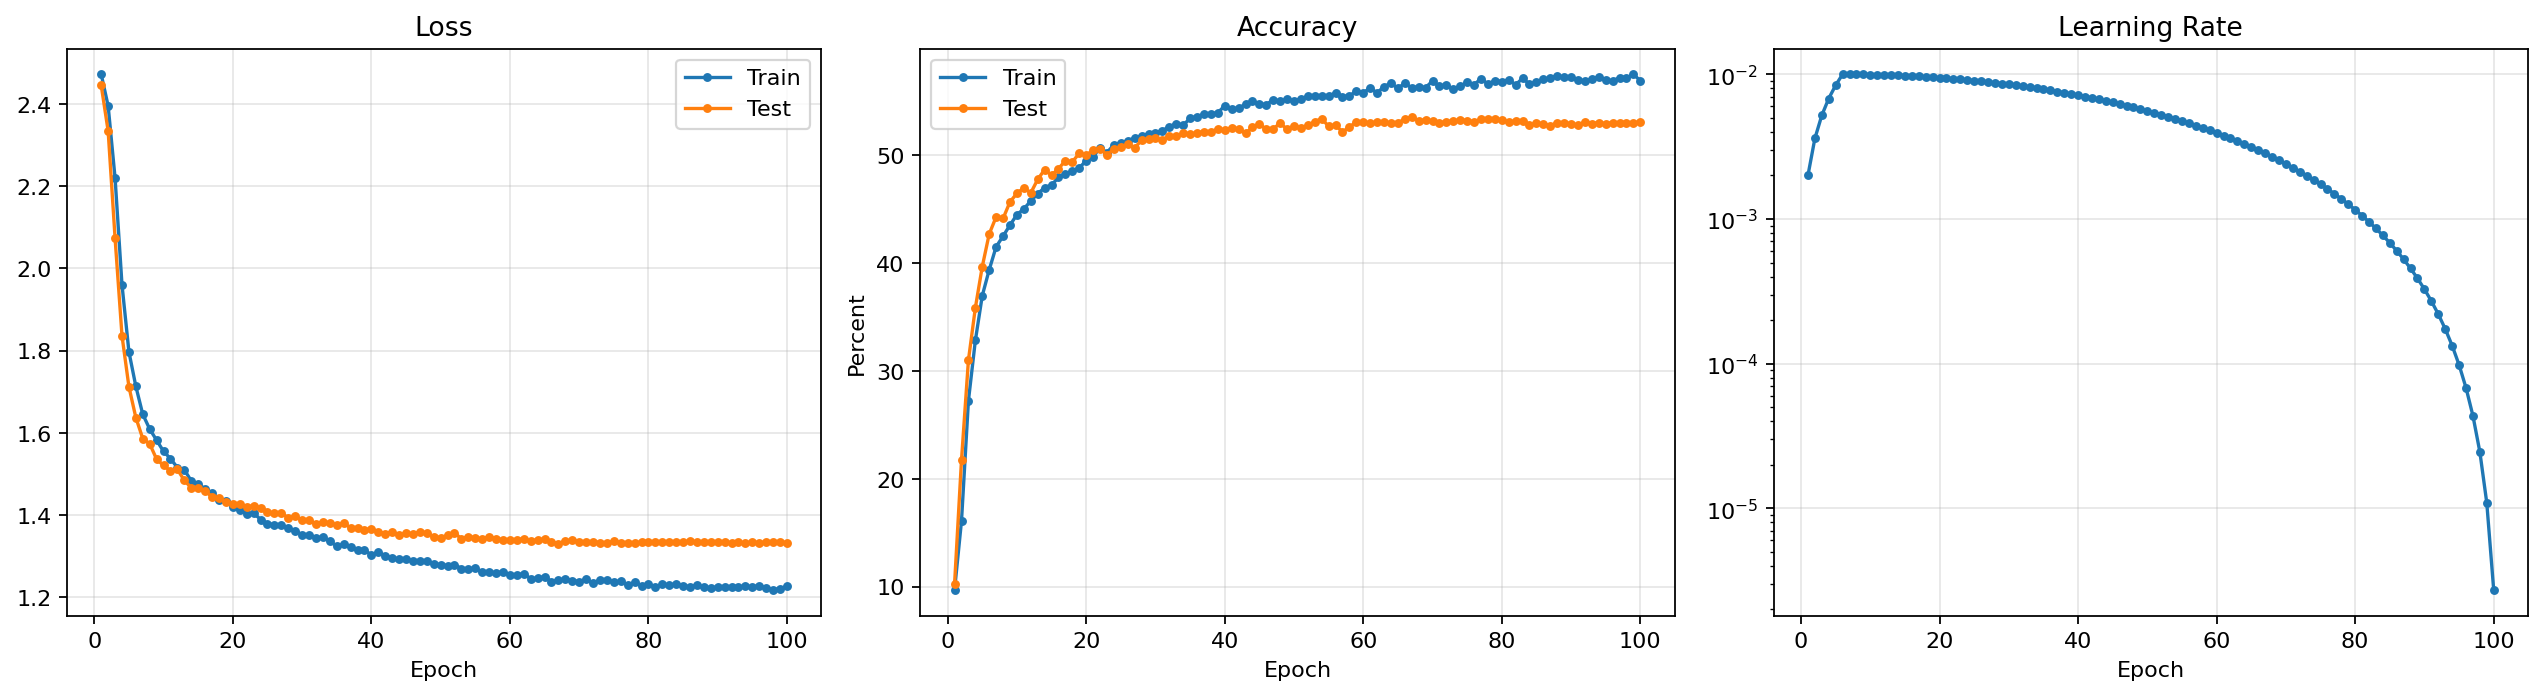

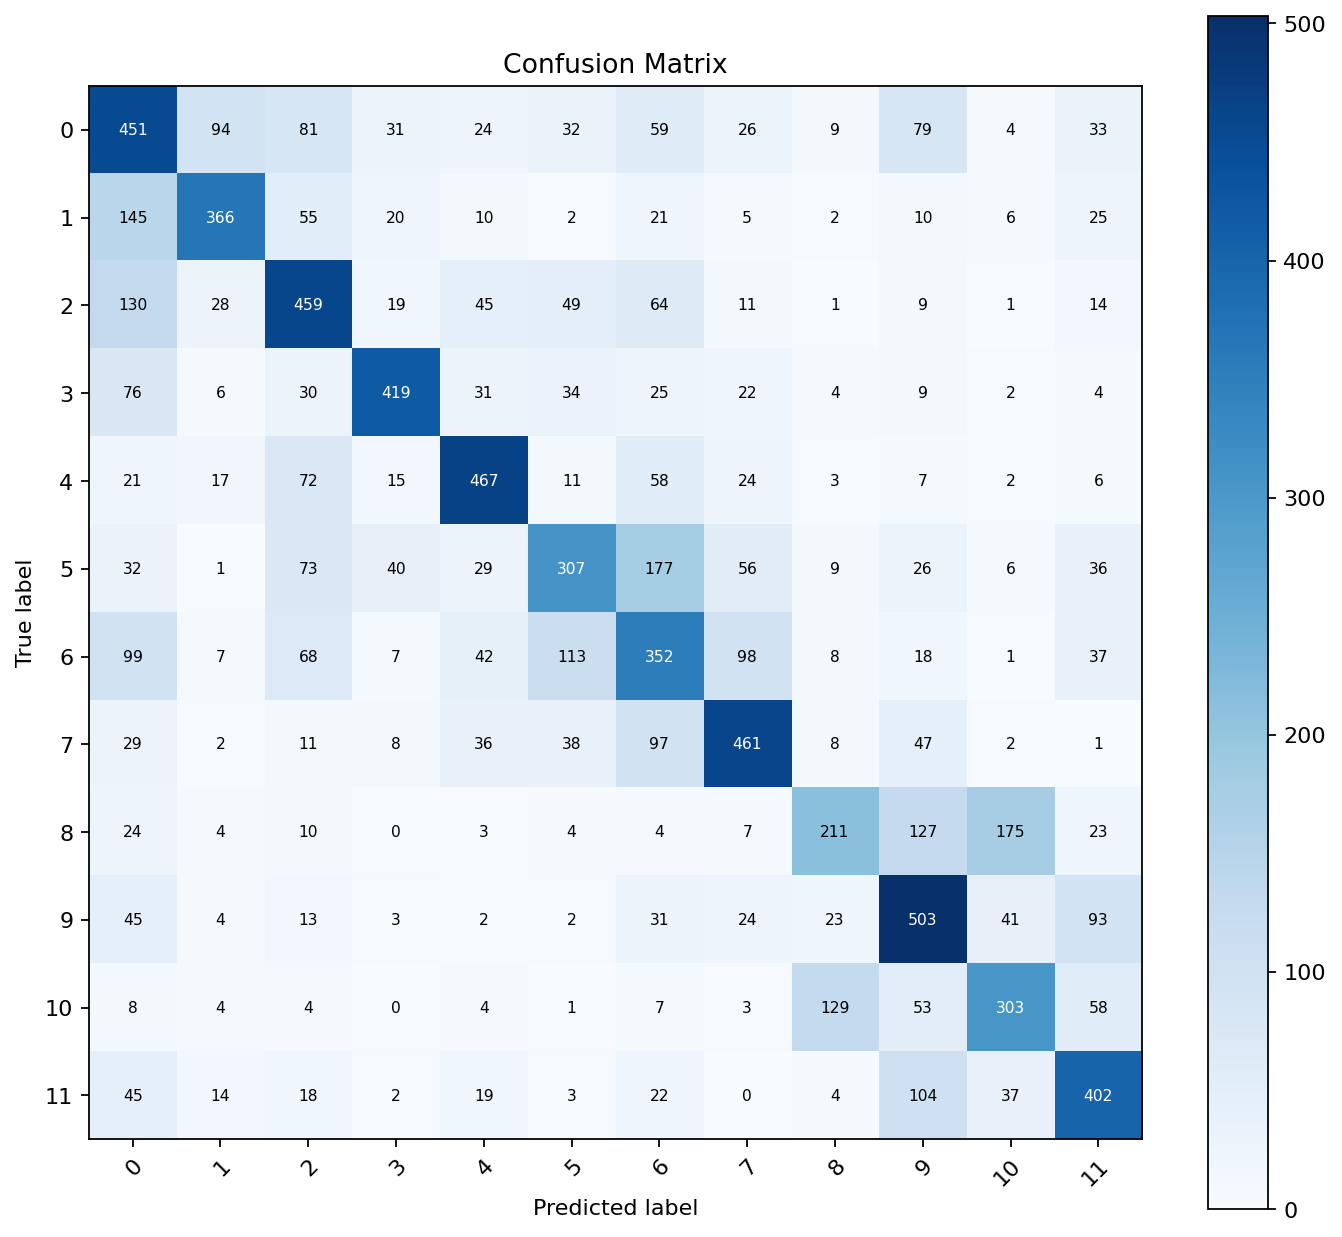

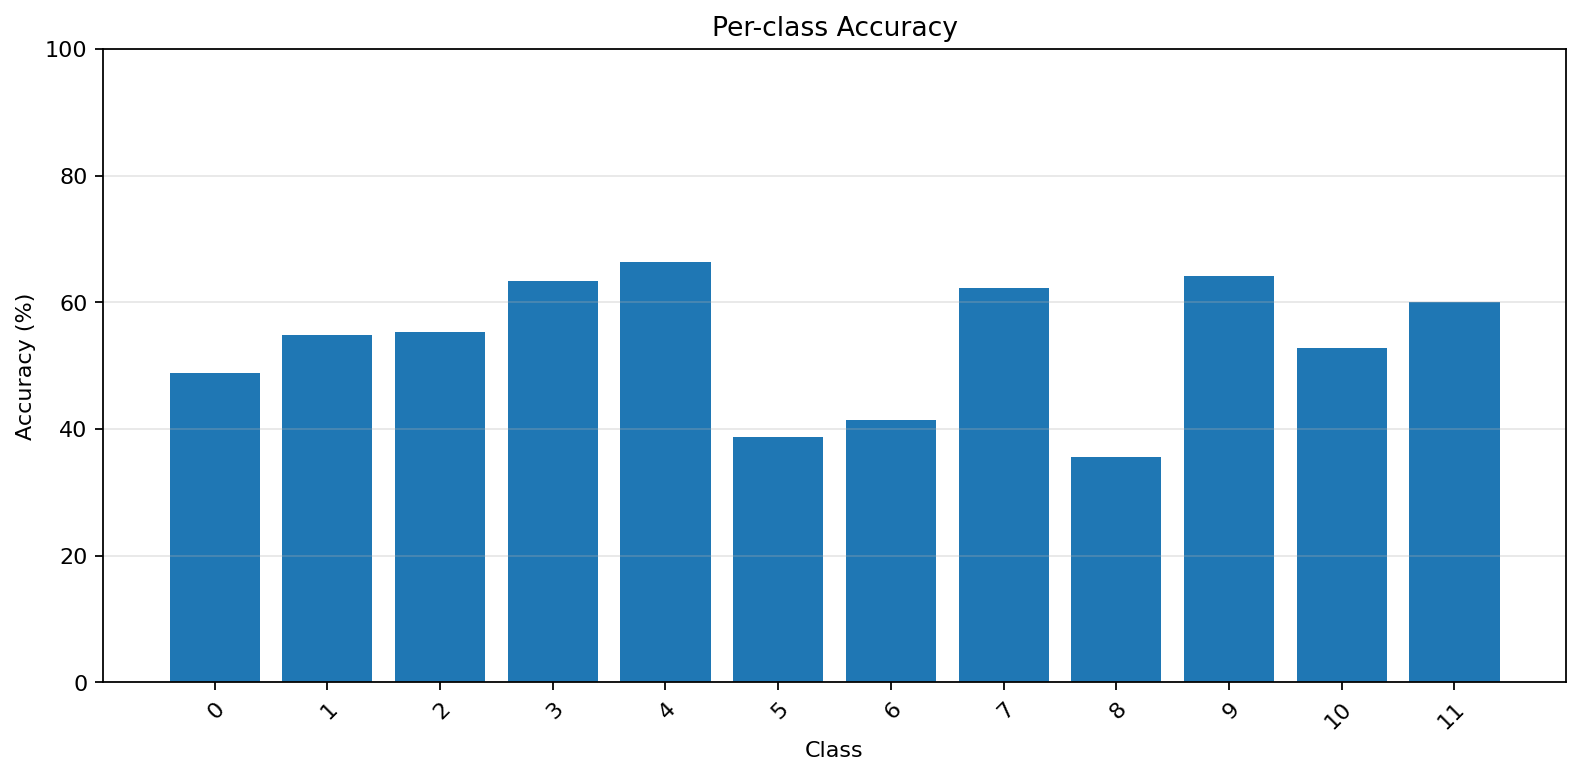

In [9]:
import json
from IPython.display import Image, display

metrics_path = OUTPUT_DIR / "metrics.json"
best_metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
print(f"best epoch       = {best_metrics['best_epoch']}")
print(f"test accuracy    = {best_metrics['accuracy'] * 100:.2f}%")
print(f"macro precision  = {best_metrics['macro_precision'] * 100:.2f}%")
print(f"macro recall     = {best_metrics['macro_recall'] * 100:.2f}%")
print(f"macro F1         = {best_metrics['macro_f1'] * 100:.2f}%")
print("注意：以上结果来自 test-selected checkpoint。")

for filename in ("training_curves.png", "confusion_matrix.png", "per_class_accuracy.png"):
    display(Image(filename=str(OUTPUT_DIR / "figures" / filename)))